<a href="https://colab.research.google.com/github/bhumika-research-04/orbital-simulation-research/blob/main/Orbital_stimulation_research.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install skyfield

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 370.4/370.4 kB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.7/235.7 kB 14.5 MB/s eta 0:00:00


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [ ]:
G = 6.67430e-11
M = 5.972e24
R_earth = 6371000

In [ ]:
altitude = 400000

r = R_earth + altitude

v = np.sqrt(G*M/r)

T = 2*np.pi*np.sqrt(r**3/(G*M))

print("Orbital velocity:",v,"m/s")
print("Orbital period:",T/60,"minutes")

Orbital velocity: 7672.4904132836045 m/s
Orbital period: 92.41555527884461 minutes


In [ ]:
x = r
y = 0

vx = 0
vy = v

dt = 1
steps = 20000

x_list = []
y_list = []

for i in range(steps):

    r_current = np.sqrt(x**2 + y**2)

    ax = -G*M*x/r_current**3
    ay = -G*M*y/r_current**3

    vx += ax*dt
    vy += ay*dt

    x += vx*dt
    y += vy*dt

    x_list.append(x)
    y_list.append(y)

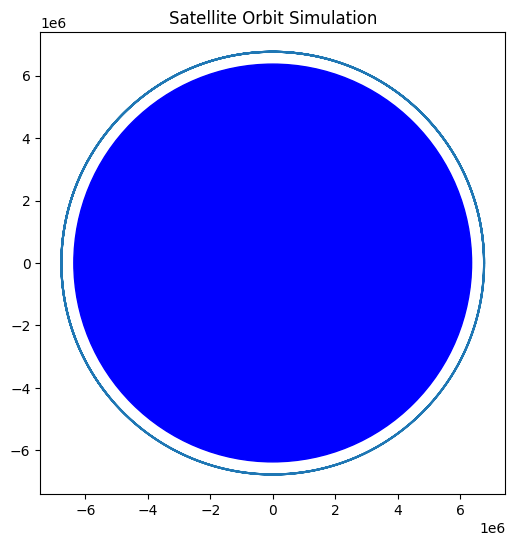

In [ ]:
plt.figure(figsize=(6,6))

earth = plt.Circle((0,0),R_earth,color='blue')
plt.gca().add_patch(earth)

plt.plot(x_list,y_list)

plt.axis('equal')
plt.title("Satellite Orbit Simulation")

plt.show()

In [ ]:
z = 0
vz = v*0.5

x_list=[]
y_list=[]
z_list=[]

for i in range(20000):

    r_current = np.sqrt(x**2+y**2+z**2)

    ax = -G*M*x/r_current**3
    ay = -G*M*y/r_current**3
    az = -G*M*z/r_current**3

    vx += ax
    vy += ay
    vz += az

    x += vx
    y += vy
    z += vz

    x_list.append(x)
    y_list.append(y)
    z_list.append(z)

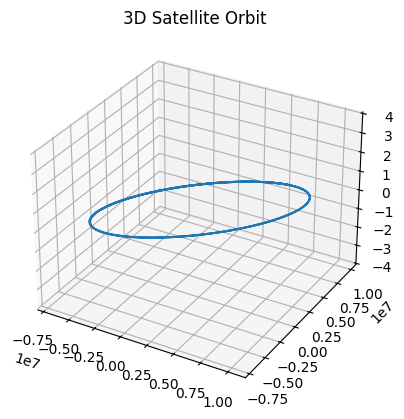

In [ ]:
fig = plt.figure()

ax = fig.add_subplot(111,projection='3d')

ax.plot(x_list,y_list,z_list)

ax.set_title("3D Satellite Orbit")

plt.show()

In [ ]:
num_satellites = 20

altitude = 550000
r = R_earth + altitude

positions=[]
velocities=[]

for i in range(num_satellites):

    angle = 2*np.pi*i/num_satellites

    x = r*np.cos(angle)
    y = r*np.sin(angle)
    z = 0

    v = np.sqrt(G*M/r)

    vx = -v*np.sin(angle)
    vy = v*np.cos(angle)
    vz = 0

    positions.append([x,y,z])
    velocities.append([vx,vy,vz])

In [ ]:
R = 6371
altitude = 550

theta = np.degrees(np.arccos(R/(R+altitude)))

print("Satellite coverage angle:",theta)

Satellite coverage angle: 22.99606076439296


In [ ]:
from skyfield.api import load, EarthSatellite

line1 = "1 25544U 98067A   24001.12345678  .00016717  00000+0  10270-3 0  9001"
line2 = "2 25544  51.6431  23.4721 0007417  72.3456 287.6543 15.49123456"

satellite = EarthSatellite(line1,line2,"ISS")

ts = load.timescale()
t = ts.now()

geocentric = satellite.at(t)

subpoint = geocentric.subpoint()

print(subpoint.latitude)
print(subpoint.longitude)

08deg 04' 02.4"
00deg 46' 07.1"
